In [1]:
from pinballrt.dust import IsotropicDust, HenyeyGreensteinDust, GeneralDust, load, suggest_opacity_sampling
from astropy.modeling import models
import astropy.units as u
import numpy as np

import subprocess

import astropy.io.fits as fits

import tempfile
from multiprocess import Pool

import os

try:
    import optool.optool
except:
    os.system("git clone https://github.com/cdominik/optool.git")
    os.chdir("optool")
    subprocess.run(["make", "multi=true"])
    subprocess.run(["make", "install", "bindir=~/.bin/"])
    subprocess.run(["pip", "install", "-e", "."])
    os.chdir("../")

/users/psheehan/Documents/pinball-warp/pinballrt/dust.py:89: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if hasattr(self, dim) and getattr(self, dim) is not None and getattr(self, dim) is not ():


In [15]:
def worker(sample):
    p = sample[0]
    a = sample[1] * u.cm
    Mcarbon = sample[2]
    
    p = optool.optool.particle(f"optool pyr-mg70 {1 - Mcarbon} c {Mcarbon} -p 0.25 -amax {a.to(u.micron).value} -apow {p} -nlam 300 -lmax 10000 -s")

    lam = p.lam * u.micron
    kabs = p.kabs[0]
    ksca = p.ksca[0]
    g = p.gsca[0]
    scattering_phase = p.f11[0]
    theta = p.scatang[0]

    return lam, kabs, ksca, g, scattering_phase, theta

In [ ]:
samples = suggest_opacity_sampling(8000, p_range=(2.5, 4.5), amax_range=(1.*u.micron, 10.*u.cm), n_dust_subspecies=2)

with Pool(6) as pool:
    results = pool.map(worker, samples)

p = samples[:,0]
amax = samples[:,1] * u.cm
Vcarbon = samples[:,2]

lam = results[0][0]  # all results should have the same lam, so we can just take it from the first one
kabs = np.array([r[1] for r in results]) * u.cm**2 / u.g
ksca = np.array([r[2] for r in results]) * u.cm**2 / u.g
g = np.array([r[3] for r in results])
scattering_phase = np.array([r[4] for r in results])

theta = results[0][5] * u.deg

np.savez("dust_data.npz", 
         kabs=kabs, 
         ksca=ksca, 
         g=g, 
         scattering_phase=scattering_phase, 
         theta=theta, 
         amax=amax, 
         p=p, 
         lam=lam, 
         Vcarbon=Vcarbon)


In [2]:
data = np.load("dust_data.npz")

kabs = data["kabs"] * u.cm**2 / u.g
ksca = data["ksca"] * u.cm**2 / u.g
g = data["g"]
scattering_phase = data["scattering_phase"]
theta = data["theta"] * u.deg
amax = data["amax"] * u.cm
p = data["p"]
lam = data["lam"] * u.micron
Vcarbon = data["Vcarbon"]

In [3]:
d = IsotropicDust(lam=lam,
                  kabs=kabs,
                  ksca=ksca,
                  amax=amax,
                  p=p,
                  abundances=(Vcarbon,),
                  fiducial_values={"amax": 3*u.mm, 
                                   "p": 3.5, 
                                   "abundances": (0.15,)})

"""d = HenyeyGreensteinDust(lam=lam, 
         kabs=kabs, 
         ksca=ksca,
         g=g,
         amax=amax, 
         p=p,
         fiducial_values={"amax": 3*u.mm, 
                          "p": 3.5, 
                          "abundances": (0.15,)})"""

"""d = GeneralDust(lam=lam,
                kabs=kabs.reshape(-1, lam.size),
                ksca=ksca.reshape(-1, lam.size),
                scattering_phase_function=scattering_phase.reshape(-1, lam.size, theta.size),
                theta=theta.to(u.radian),
                amax=amax,
                p=p,
                default_fiducial_values={"amax": 3*u.mm, 
                                         "p": 3.5, 
                                         "abundances": (0.15,)})"""

'd = GeneralDust(lam=lam,\n                kabs=kabs.reshape(-1, lam.size),\n                ksca=ksca.reshape(-1, lam.size),\n                scattering_phase_function=scattering_phase.reshape(-1, lam.size, theta.size),\n                theta=theta.to(u.radian),\n                amax=amax,\n                p=p)'

In [108]:
for model in ["kabs", "ksca", "pmo", "random_nu"]:
#for model in ["kabs", "ksca", "pmo", "scattering_phase_function", "random_nu", "random_direction"]:
#for model in ["scattering_phase_function"]:
#for model in ["random_direction"]:
    print("*******************************")
    print(model)
    print("*******************************")

    if model in ["random_direction"]:
        hidden_units = (48,)*6
    elif model in ["random_nu"]:
        hidden_units = (48,)*6
        batch_size = 10000000
    else:
        hidden_units = (32,)*6
        batch_size = 100000
        
    d.learn(model=model, nsamples=1000, hidden_units=hidden_units, overwrite=True)

    d.fit(epochs=5000, batch_size=100000, num_workers=50)
    d.test_model(plot=True)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


*******************************
random_nu
*******************************


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/lustre/cv/users/psheehan/.conda/envs/pinball-rt/lib/python3.13/site-packages/astropy/units/quantity.py:653: RuntimeWarning: overflow encountered in expm1
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/lustre/cv/users/psheehan/.conda/envs/pinball-rt/lib/python3.13/site-packages/astropy/units/quantity.py:653: RuntimeWarning: overflow encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/lustre/cv/users/psheehan/.conda/envs/pinball-rt/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /users/psheehan/Documents/pinball-warp/examples/random_nu_lightning_logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type                 | Params | Mode 
-------------------------------------------------------
0 | model | MultiLayerPerc

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/lustre/cv/users/psheehan/.conda/envs/pinball-rt/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


p: 4.398709161558942, amax: 0.031783722019888265, T: 877.9492371803229, abundances: [np.float64(0.7058875657301152)]


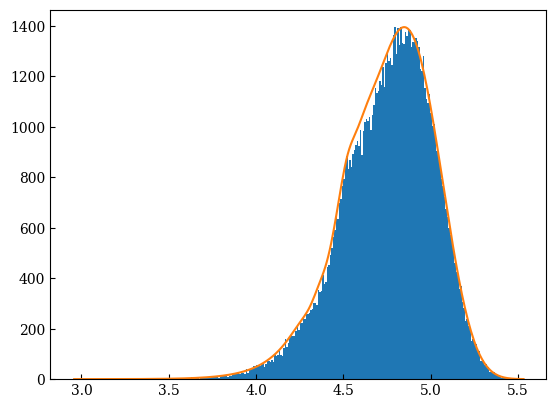

In [130]:
d.plot_random_nu_model()

In [5]:
d.save("diana.iso.dst")